In [1]:
from RNN import RNN, ExpRNN
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# EXPONENTIAL DECAY

In [78]:
domain = torch.linspace(0,1,500)
exponents = torch.linspace(-3., 0, 50)
full_data = torch.exp(exponents[:,None] * domain[None,:])
train_data = full_data[::2]
test_data = full_data[1::2]
train_data.shape, test_data.shape

(torch.Size([25, 500]), torch.Size([25, 500]))

In [79]:
regmodel = RNN(input_size=1, output_size=1, bottleneck_size=128)
expmodel = ExpRNN(input_size=1, output_size=1, bottleneck_size=128)
regoptim = torch.optim.AdamW(regmodel.parameters(), lr=1e-4)
expoptim = torch.optim.AdamW(expmodel.parameters(), lr=1e-4)

In [80]:
def train(model, optim, num_epochs, data, loss_fn = torch.nn.MSELoss()):
    for epoch in range(num_epochs):
        if epoch % 10 == 1:
            print(epoch, loss.item())
        optim.zero_grad()
        #Seems like an issue I had was I was feeding the data incorrectly. The network was predicting x from x, not x_t+1 from x_t
        y, _ = model(data[:,:-1,:])
        loss = loss_fn(y, data[:,1:,:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()
    print(epoch, loss.item())

In [81]:
train(regmodel, regoptim, 300, train_data.unsqueeze(-1))
train(expmodel, expoptim, 300, train_data.unsqueeze(-1))

1 0.10135660320520401
11 0.05141443386673927
21 0.03966325893998146
31 0.03630105033516884
41 0.03368619456887245
51 0.030206436291337013
61 0.028925087302923203
71 0.02378208003938198
81 0.01861020177602768
91 0.01542080007493496
101 0.011433354578912258
111 0.00899430736899376
121 0.008018541149795055
131 0.008168075233697891
141 0.007486040238291025
151 0.0075117372907698154
161 0.006580802146345377
171 0.0061605158261954784
181 0.005811898037791252
191 0.005482313688844442
201 0.0056988256983459
211 0.005368321668356657
221 0.005460282787680626
231 0.004688012879341841
241 0.0042723179794847965
251 0.004321205895394087
261 0.004212534055113792
271 0.0038859157357364893
281 0.0038012464065104723
291 0.0037848406936973333
299 0.0033407555893063545
1 0.2204114943742752
11 0.015940546989440918
21 0.007158156018704176
31 0.005350894760340452
41 0.0041724154725670815
51 0.0031424611806869507
61 0.0021997787989676
71 0.0017304737120866776
81 0.002194698667153716
91 0.0015606211964040995
1

In [82]:
def gen_preds(model):
    model.eval()
    test_data_batch = test_data.unsqueeze(-1)
    batch_size, time_steps, _ = test_data_batch.shape

    # Store the results
    result = torch.zeros_like(test_data_batch)

    # Define how many steps to "prime" the model with
    priming_steps = 100

    with torch.no_grad():
        # 1. PRIME THE MODEL
        # Feed the priming sequence to get the starting hidden state
        prime_input = test_data_batch[:, :priming_steps, :]
        _, hidden_state = model(prime_input)

        # Copy the ground truth priming data to our results
        result[:, :priming_steps, :] = prime_input

        # The last real data point is our first input for generation
        current_point = test_data_batch[:, priming_steps-1, :].unsqueeze(1)

        # 2. GENERATE AUTOREGRESSIVELY
        for t in range(priming_steps, time_steps):
            # Pass only the LAST point and the PREVIOUS hidden state
            output, hidden_state = model(current_point, hidden_state)

            # Store the prediction
            result[:, t, :] = output.squeeze(1)

            # The next input is the prediction we just made
            current_point = output

    return result

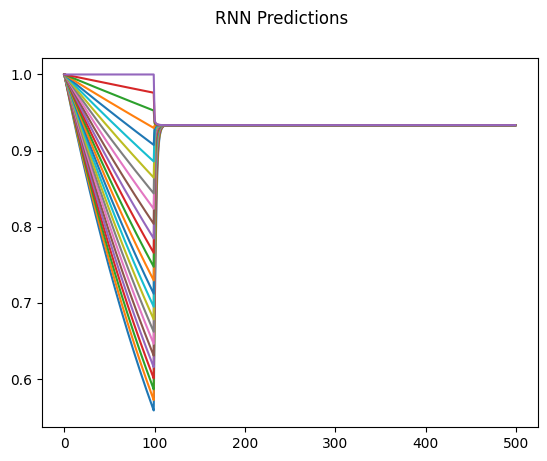

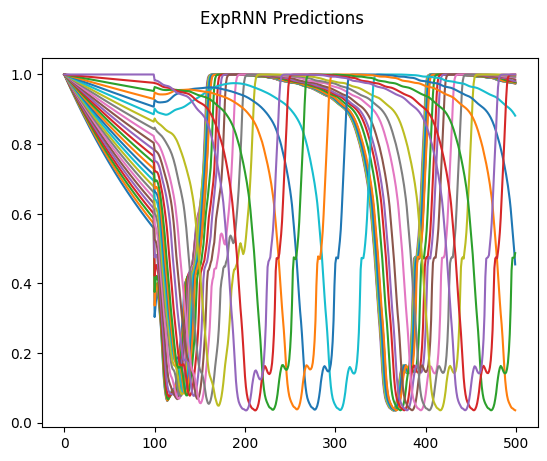

In [83]:
for model, name in [(regmodel, "RNN"), (expmodel, "ExpRNN")]:
    result = gen_preds(model)
    plt.plot(result.squeeze().T)
    plt.suptitle(f"{name} Predictions")
    plt.show()

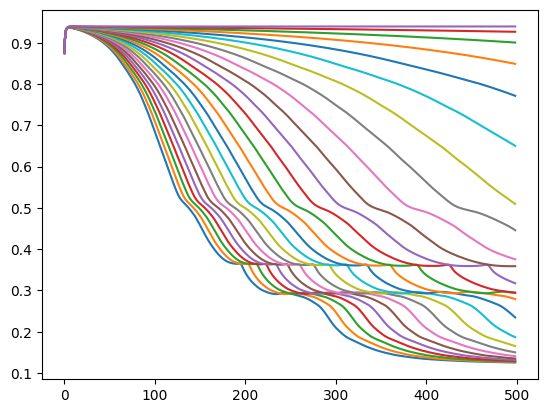

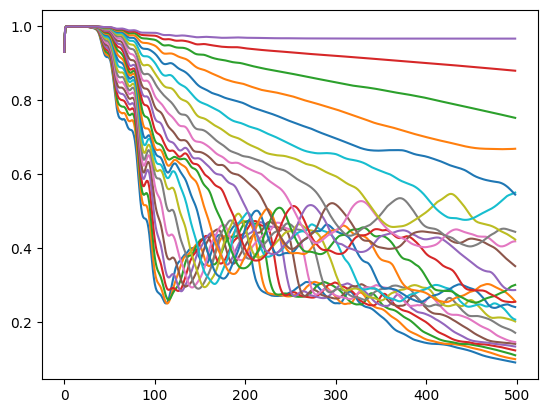

In [91]:
res, _ = regmodel(test_data.unsqueeze(-1)[:,:-1,:])
plt.plot(res.detach().numpy().squeeze().T)
plt.show()
res, _ = expmodel(test_data.unsqueeze(-1)[:,:-1,:])
plt.plot(res.detach().numpy().squeeze().T)

# ALPHABET

In [123]:
#Testing classification
alphabet = {0:"a", 1:"b", 2:"c", 3:"d", 4:"e", 5:"f", 6:"g", 7:"h", 8:"i", 9:"j", 10:"k", 11:"l", 12:"m", 13:"n", 14:"o", 15:"p", 16:"q", 17:"r", 18:"s", 19:"t", 20:"u", 21:"v", 22:"w", 23:"x", 24:"y", 25:"z"}
alphabet_size = len(alphabet)
num_batches = 26
# 1. Create broadcastable range tensors for batch and sequence indices
batch_indices = torch.arange(num_batches).view(num_batches, 1)
sequence_indices = torch.arange(alphabet_size).view(1, alphabet_size)

# 2. Add them together. Broadcasting creates a (26, 26) matrix
#    where each row is shifted by 1 from the previous row.
#    The modulo operator handles the cyclic wrap-around.
shifted_indices = (batch_indices + sequence_indices) % alphabet_size

# 3. Use the shifted indices to gather one-hot vectors from an identity matrix.
#    This is a powerful indexing operation that builds the final tensor in one step.
train_data = torch.eye(alphabet_size)[shifted_indices]

#Original training data setup which lead to pattern overfitting.
#train_data = torch.stack([torch.eye(26) for _ in range(26)], dim=0) #Stacking due to batchnorm issues
#a_vector_batch = train_data[:, 0:1, :] #get just a and add it at the end for looping
#train_data = torch.cat([train_data, a_vector_batch], dim=1)

In [124]:
train_data.shape

torch.Size([26, 26, 26])

In [125]:
classmodel = RNN(input_size=26, output_size=26, bottleneck_size=128, output_activation=nn.Identity)
classoptim = torch.optim.AdamW(classmodel.parameters(), lr=1e-3)

In [126]:
train(classmodel, classoptim, 500, train_data, loss_fn=nn.CrossEntropyLoss())

1 3.1535775661468506
11 1.0698062181472778
21 0.2852945923805237
31 0.09001611918210983
41 0.04237617552280426
51 0.026568422093987465
61 0.019596748054027557
71 0.01575763337314129
81 0.01326750312000513
91 0.01146451011300087
101 0.010067292489111423
111 0.008939654566347599
121 0.008006524294614792
131 0.007221393287181854
141 0.006552678067237139
151 0.005977630615234375
161 0.005479017738252878
171 0.005043546669185162
181 0.004660815931856632
191 0.004322407301515341
201 0.004021582659333944
211 0.0037529333494603634
221 0.003511823480948806
231 0.003294610418379307
241 0.0030981111340224743
251 0.0029197160620242357
261 0.0027572382241487503
271 0.002608746290206909
281 0.002472694730386138
291 0.002347597386687994
301 0.0022323857992887497
311 0.002125969622284174
321 0.0020274315029382706
331 0.001936037209816277
341 0.0018510438967496157
351 0.001771870767697692
361 0.001697985571809113
371 0.0016289243940263987
381 0.001564235775731504
391 0.0015035367105156183
401 0.0014465

In [127]:
res, _ = classmodel(train_data[:,:-1,:])
res.argmax(dim=-1)

tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
         19, 20, 21, 22, 23, 24, 25],
        [ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
         20, 21, 22, 23, 24, 25,  0],
        [ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
         21, 22, 23, 24, 25,  0,  1],
        [ 4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,
         22, 23, 24, 25,  0,  1,  2],
        [ 5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
         23, 24, 25,  0,  1,  2,  3],
        [ 6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
         24, 25,  0,  1,  2,  3,  4],
        [ 7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24,
         25,  0,  1,  2,  3,  4,  5],
        [ 8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25,
          0,  1,  2,  3,  4,  5,  6],
        [ 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,

In [147]:
history = []
start_letter = 25
first_input = train_data[:,start_letter:start_letter+1,:]
#print(first_input)
next_input, hidden_state = classmodel(first_input)
history.append(next_input)
for t in range(1, 1000):
    next_input, hidden_state = classmodel(next_input, hidden_state)
    history.append(next_input)
history = torch.stack(history, dim=1).squeeze()

In [150]:
picked_letter = history.argmax(dim=-1)
for run in picked_letter:
    out = ""
    for idx in run:
        out += alphabet[idx.item()]
    print(out[-10:])
#Interesting how it overfits to the pattern if no shuffling is enabled. To prevent the net from always predicting "bcd..." I will shift the sequence in the batch dimension.

cdefghijkl
defghijklm
efghijklmn
fghijklmno
ghijklmnop
hijklmnopq
ijklmnopqr
jklmnopqrs
klmnopqrst
lmnopqrstu
mnopqrstuv
nopqrstuvw
opqrstuvwx
pqrstuvwxy
qrstuvwxyz
rstuvwxyza
stuvwxyzab
tuvwxyzabc
uvwxyzabcd
vwxyzabcde
wxyzabcdef
xyzabcdefg
yzabcdefgh
zabcdefghi
abcdefghij
bcdefghijk


# CUSTOM SEQUENCE

In [55]:
# The goal of this sequence is to learn a code-blank-start pattern. There is a numerical code (eg 123), a blank character (eg "-") and a start character (eg :). The network is fed a sequence like 123-----:-- and it must retrieve the code as --------123, where the first number comes in at start. All characters are one-hot encoded.
code_alphabet = {0:"0", 1:"1", 2:"2", 3:"3", 4:"4", 5:"5", 6:"6", 7:"7", 8:"8", 9:"9", 10:"-", 11:":"}
num_messages = 1000
code_length = 3
empty_length = 4
torch.manual_seed(0)
one_hots = torch.eye(12)
#BUILDS THE MESSAGE
code = one_hots[torch.randint(0, 10, (num_messages, code_length))] #Code is a sequence of 3 random integers from 0-9
empty = one_hots[torch.full((num_messages, empty_length), 10)] #Empty space is a sequence of 5 "-" characters
code_space = one_hots[torch.full((num_messages, code_length - 1), 10)]
start = one_hots[torch.full((num_messages, 1), 11)]
messages = torch.cat([code, empty, start, code_space], dim=1)
#BUILDS THE RESPONSE
pre_message = one_hots[torch.full((num_messages, code_length + empty_length), 10)]
responses = torch.cat([pre_message, code], dim=1)
targets = responses.argmax(dim=-1)

In [56]:
memory_rnn = RNN(input_size=12, output_size=12, bottleneck_size=256, hidden_sizes=(512, 256, 128), output_activation=nn.Identity, weight_activation=nn.LeakyReLU(negative_slope=-1))

In [60]:
memory_optim = torch.optim.AdamW(memory_rnn.parameters(), lr=1e-4)

In [61]:
for epoch in range(200):
    if epoch % 10 == 1:
        print(epoch, loss.item())
    memory_optim.zero_grad()
    #Seems like an issue I had was I was feeding the data incorrectly. The network was predicting x from x, not x_t+1 from x_t
    y, _ = memory_rnn(messages)
    loss = nn.CrossEntropyLoss()(y.view(-1, 12), targets.view(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(memory_rnn.parameters(), 1.0)
    memory_optim.step()
print(epoch, loss.item())

1 0.024149956181645393
11 0.0016480726189911366
21 0.001117828767746687
31 0.0007650231127627194
41 0.0005938217509537935
51 0.00048673091805540025
61 0.00041681548464111984
71 0.00036537079722620547
81 0.0003243264218326658
91 0.00029097351944074035
101 0.0002629817754495889
111 0.00023908005096018314
121 0.00021831845515407622
131 0.0002001934772124514
141 0.00018423206347506493
151 0.00017007153655868024
161 0.00015748183068353683
171 0.000146264472277835
181 0.00013620320532936603
191 0.00012714469630736858
199 0.00011972180800512433


In [62]:
res, _ = memory_rnn(messages)
idxs = res.argmax(dim=-1)
for i, idx in enumerate(idxs):
    res = ""
    resp = ""
    for j in range(len(idx)):
        res += code_alphabet[idx[j].item()]
        resp += code_alphabet[responses[i][j].argmax().item()]
    print(res, "\n", resp)

-------493 
 -------493
-------039 
 -------039
-------737 
 -------737
-------316 
 -------316
-------698 
 -------698
-------668 
 -------668
-------436 
 -------436
-------914 
 -------914
-------419 
 -------419
-------990 
 -------990
-------123 
 -------123
-------055 
 -------055
-------291 
 -------291
-------883 
 -------883
-------691 
 -------691
-------735 
 -------735
-------210 
 -------210
-------931 
 -------931
-------103 
 -------103
-------667 
 -------667
-------963 
 -------963
-------450 
 -------450
-------828 
 -------828
-------275 
 -------275
-------008 
 -------008
-------196 
 -------196
-------102 
 -------102
-------943 
 -------943
-------939 
 -------939
-------398 
 -------398
-------532 
 -------532
-------856 
 -------856
-------657 
 -------657
-------256 
 -------256
-------654 
 -------654
-------081 
 -------081
-------785 
 -------785
-------448 
 -------448
-------449 
 -------449
-------074 
 -------074
-------533 
 -------533
-------730 
 ---